# Домашнее задание: Кластеризация клиентов

Вторая часть задания (PCA и t-SNE) будет рассмотрена на следующем занятии.

---

## 1. Введение

В этом задании вы будете работать с датасетом Customer Segmentation Dataset, который содержит данные о клиентах торгового центра. Ваша задача: применить методы кластеризации для выявления групп клиентов со схожим поведением.

### Цель задания:

- Применить алгоритмы K-Means и DBSCAN для сегментации клиентов
- Сравнить результаты работы двух методов кластеризации
- Проанализировать полученные сегменты и сделать выводы о том, какие группы клиентов можно выделить
- Определить, какой метод кластеризации лучше подходит для данной задачи

---

## 2. Описание датасета

Customer Segmentation Dataset содержит информацию о 200 клиентах торгового центра.

### Признаки в датасете:

| Признак | Описание |
|---------|----------|
| `CustomerID` | Уникальный идентификатор клиента (используется только для идентификации, не участвует в кластеризации) |
| `Gender` | Пол клиента (Male/Female) |
| `Age` | Возраст клиента в годах |
| `Annual Income (k$)` | Годовой доход клиента в тысячах долларов |
| `Spending Score (1-100)` | Оценка покупательского поведения, присвоенная клиенту на основе истории покупок (от 1 до 100, где 100 — максимальная активность покупок) |

### Задачи сегментации:

В этом задании вы будете искать группы клиентов на основе следующих гипотез:

1. Клиенты с высоким доходом и высокими расходами (VIP-сегмент)
2. Клиенты с высоким доходом, но низкими расходами (потенциал для маркетинговых акций)
3. Клиенты со средним доходом и средними расходами (основной сегмент)
4. Клиенты с низким доходом и низкими расходами (бюджетный сегмент)
5. Другие возможные паттерны

---

## 3. Загрузка датасета

### Способ 1: Загрузка через Python (рекомендуется)

In [1]:
import pandas as pd

# Загрузка датасета
url = "https://raw.githubusercontent.com/InfiniteJas/MLcourse/main/week10/Mall_Customers.csv"
df = pd.read_csv(url)

# Просмотр первых строк
print(df.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


### Способ 2: Ручная загрузка

1. Перейдите по ссылке: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python
2. Скачайте файл `Mall_Customers.csv`
3. Загрузите его в Python:

```python
df = pd.read_csv("Mall_Customers.csv")
```

---

## 4. Задачи

### Часть 1: Предварительный анализ данных

Перед применением алгоритмов кластеризации необходимо изучить датасет.

**Задания:**

1. Выведите информацию о датасете (количество строк, столбцов, типы данных)
2. Проверьте наличие пропущенных значений
3. Постройте гистограммы распределения для признаков `Age`, `Annual Income (k$)` и `Spending Score (1-100)`
4. Постройте scatter plot (точечную диаграмму) для пар признаков:
   - `Annual Income` vs `Spending Score`
   - `Age` vs `Spending Score`
   
**Что анализировать:**
- Есть ли видимые кластеры на scatter plot? -Да, отчетливо выделяются группы
- Какие закономерности можно заметить до применения алгоритмов? - клиенты с одинаковым доходом могут иметь как высокие, так и низкие траты. Молодые клиенты чаще имеют высокий spending score, взрослые клиенты имеют умеренные или низкие траты

Общая информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
Количество пропусков:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


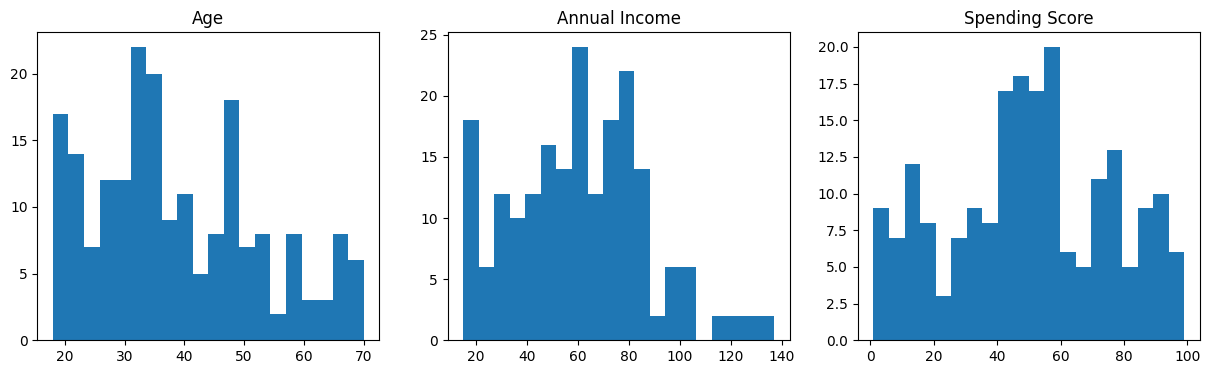

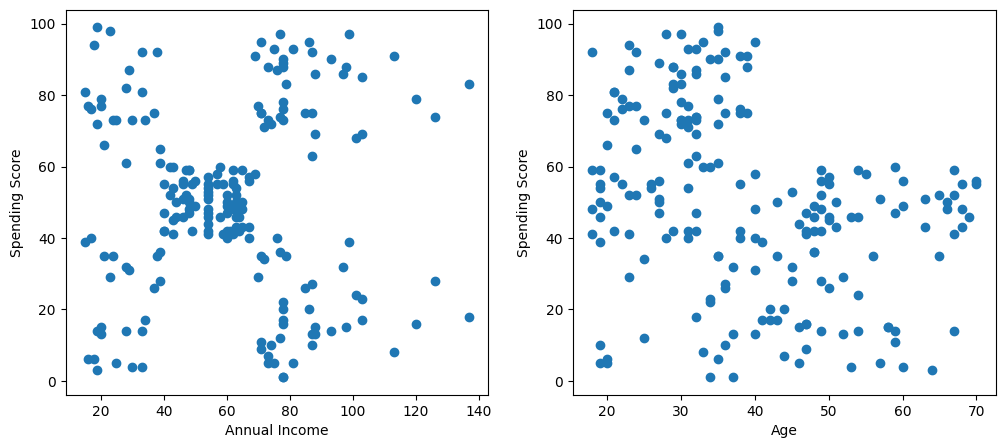

In [2]:
# Ваш код здесь
import matplotlib.pyplot as plt
import seaborn as sns

print('Общая информация:')
print(df.info())

print('Количество пропусков:')
print(df.isnull().sum())

# Гистограммы
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.hist(df['Age'], bins=20)
plt.title('Age')

plt.subplot(1, 3, 2)
plt.hist(df['Annual Income (k$)'], bins=20)
plt.title('Annual Income')

plt.subplot(1, 3, 3)
plt.hist(df['Spending Score (1-100)'], bins=20)
plt.title('Spending Score')

plt.show()

# Scatter plots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.subplot(1, 2, 2)
plt.scatter(df['Age'], df['Spending Score (1-100)'])
plt.xlabel('Age')
plt.ylabel('Spending Score')

plt.show()



### Часть 2: Подготовка данных

Перед кластеризацией данные необходимо предобработать.

**Задания:**

1. Удалите столбцы `CustomerID` и `Gender` (в данном задании пол не используется для кластеризации)
2. Создайте новый DataFrame, содержащий только признаки для кластеризации: `Age`, `Annual Income (k$)`, `Spending Score (1-100)`
3. Примените стандартизацию данных с помощью `StandardScaler` из библиотеки `sklearn.preprocessing`

**Пример кода для стандартизации:**

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']])
```

**Вопрос для анализа:**
- Почему необходимо стандартизировать данные перед кластеризацией? - Стандартизация нужна, потому что признаки имеют разные масштабы измерения, модель будет брать признаки свысокими значениями в приоритет

In [3]:
# Ваш код здесь
from sklearn.preprocessing import StandardScaler

df_features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_features)


### Часть 3: K-Means

Примените алгоритм K-Means для сегментации клиентов.

**Задания:**

1. Запустите K-Means с разными значениями K (количество кластеров): K = 3, 4, 5, 6
2. Для каждого значения K вычислите метрику WCSS (Within-Cluster Sum of Squares) — сумму квадратов расстояний внутри кластеров. Эта метрика доступна через атрибут `inertia_` модели K-Means.
3. Постройте график зависимости WCSS от K (метод локтя / Elbow Method)
4. Определите оптимальное значение K на основе графика
5. Обучите K-Means с оптимальным K
6. Вычислите силуэтный коэффициент (Silhouette Score) для оценки качества кластеризации
7. Постройте scatter plot для визуализации кластеров (используйте два признака: `Annual Income` и `Spending Score`)

**Пример кода для K-Means:**

```python
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Обучение K-Means
kmeans = KMeans(n_clusters=5, random_state=42, init='k-means++')
labels = kmeans.fit_predict(df_scaled)

# Силуэтный коэффициент
silhouette_avg = silhouette_score(df_scaled, labels)
print(f"Силуэтный коэффициент: {silhouette_avg:.3f}")
```

**Вопросы для анализа:**

- Какое оптимальное значение K вы выбрали на основе метода локтя? - К = 5
- Что показывает силуэтный коэффициент? (Значения от -1 до 1: чем ближе к 1, тем лучше) - показывает 0.408, довольно хорошее разбиение, но не идеальное
- Какие сегменты клиентов можно выделить? -
1. Клиенты с высоким доходом и высокими расходами,
2. клиенты с высоким доходом и низкими расходами,
3. клиенты со средним доходом и средними расходами,
4. клиенты с низким доходом и низкими расходами,
5. клиенты с низким доходом и высокими расходами
- Опишите характеристики каждого кластера (средний возраст, доход, расходы)
1. возраст средний или выше среднего, высокий доход, высокие расходы
2. средний возраст, высокий доход, низкие расходы
3. средний возраст, доход и расход
4. более высокий средний возраст, низкий доход и низкие расходы
5. низкий или средний доход, низкий возраст, высокие расходы

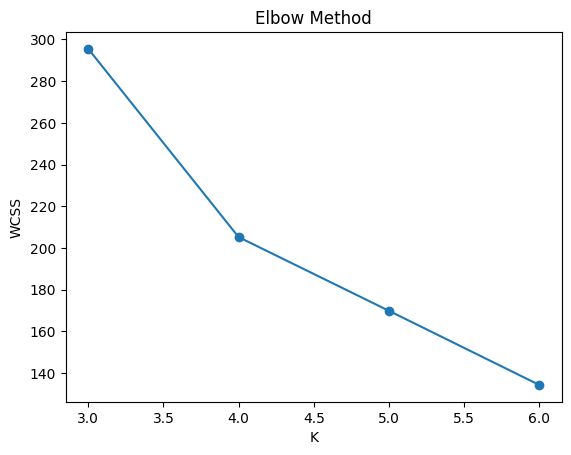

Silhouette Score: 0.408


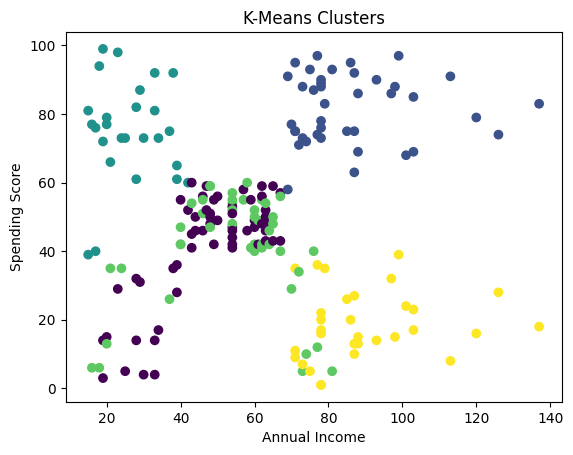

In [4]:
# Ваш код здесь
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

wcss = []
K_range = range(3, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++')
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Elbow method
plt.plot(K_range, wcss, marker='o')
plt.xlabel('K')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

# Оптимальный K
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels_kmeans = kmeans.fit_predict(df_scaled)

# Силуэтный коэффициент
silhouette_avg = silhouette_score(df_scaled, labels_kmeans)
print(f"Silhouette Score: {silhouette_avg:.3f}")

# Визуализация
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=labels_kmeans)
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('K-Means Clusters')
plt.show()


### Часть 4: DBSCAN

Примените алгоритм DBSCAN для сегментации клиентов.

**Задания:**

1. Запустите DBSCAN с разными комбинациями параметров:
   - `eps=0.5, min_samples=5`
   - `eps=0.7, min_samples=10`
   - `eps=1.0, min_samples=5`
2. Для каждой комбинации параметров определите:
   - Количество найденных кластеров
   - Количество точек, определенных как выбросы (метка -1)
3. Визуализируйте результаты кластеризации DBSCAN (scatter plot с выделением выбросов отдельным цветом)
4. Выберите оптимальную комбинацию параметров

**Пример кода для DBSCAN:**

```python
from sklearn.cluster import DBSCAN

# Обучение DBSCAN
dbscan = DBSCAN(eps=0.7, min_samples=10)
labels = dbscan.fit_predict(df_scaled)

# Подсчет кластеров и выбросов
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_outliers = list(labels).count(-1)

print(f"Количество кластеров: {n_clusters}")
print(f"Количество выбросов: {n_outliers}")
```

**Вопросы для анализа:**

- Как изменение параметров `eps` и `min_samples` влияет на результаты кластеризации? - eps уменьшает количество выбросов при увеличении, а min_samples увеличивает количество выбросов при увеличении
- Сколько выбросов обнаружил DBSCAN? -
1. При eps=0.5, min_samples=5 - 60 выбрасов
2. При eps=0.7, min_samples=10 - 43 выброса
3. При eps=1.0, min_samples=5 - 2 выброса
- Можете ли вы объяснить, почему эти точки определены как выбросы? - уних нестандартные метрики, такие точки находятся на границах групп

eps=0.5, min_samples=5
Clusters: 6, Outliers: 60



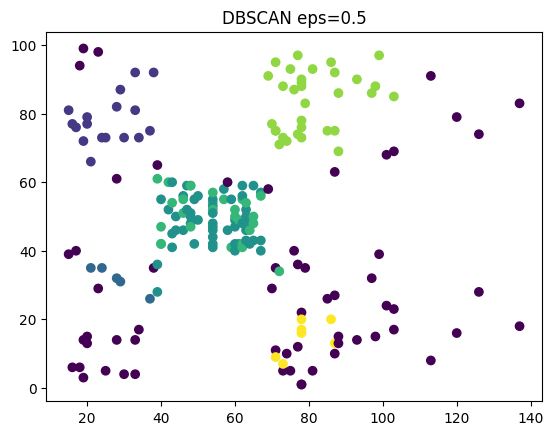

eps=0.7, min_samples=10
Clusters: 2, Outliers: 43



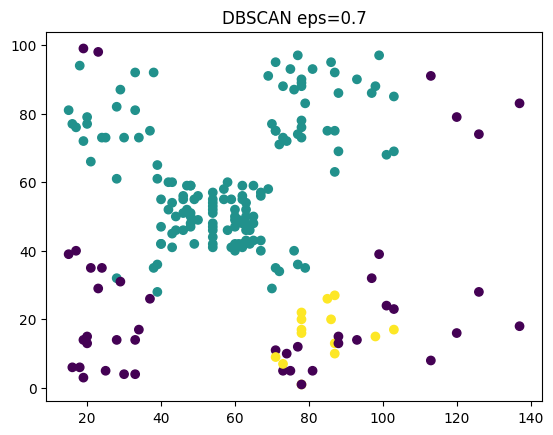

eps=1.0, min_samples=5
Clusters: 1, Outliers: 2



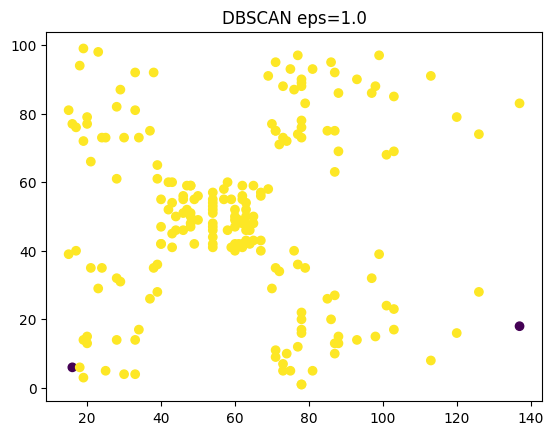

In [5]:
# Ваш код здесь
from sklearn.cluster import DBSCAN

params = [
    (0.5, 5),
    (0.7, 10),
    (1.0, 5)
]

for eps, min_samples in params:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(df_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_outliers = list(labels).count(-1)

    print(f"eps={eps}, min_samples={min_samples}")
    print(f"Clusters: {n_clusters}, Outliers: {n_outliers}\n")

    plt.scatter(
        df['Annual Income (k$)'],
        df['Spending Score (1-100)'],
        c=labels
    )
    plt.title(f"DBSCAN eps={eps}")
    plt.show()


### Часть 5: Сравнение методов

Сравните результаты K-Means и DBSCAN.

**Задания:**

1. Создайте таблицу сравнения:
   - Количество кластеров
   - Силуэтный коэффициент (для K-Means)
   - Количество выбросов (для DBSCAN)
2. Постройте scatter plots для обоих методов рядом для визуального сравнения
3. Ответьте на вопросы:
   - Какой метод лучше справился с сегментацией клиентов в данном датасете? - K-means
   - В каких случаях предпочтительнее использовать K-Means, а в каких — DBSCAN? - K-Means предпочтительнее, когда заранее известно или предполагается количество кластеров, DBSCAN лучше использовать, когда важно выявлять выбросы или когда кластеры имеют сложную форму и разную плотность
   - Согласны ли вы с сегментацией, предложенной алгоритмами? Почему? - Да, согласен. Группы клиентов хорошо согласуются с бизнес-гипотезами о поведении покупателей и могут быть использованы для разработки маркетинговых стратегий

     Метод  Количество кластеров  Silhouette Score  Количество выбросов
0  K-Means                     5          0.408469                    0
1   DBSCAN                     1               NaN                    2


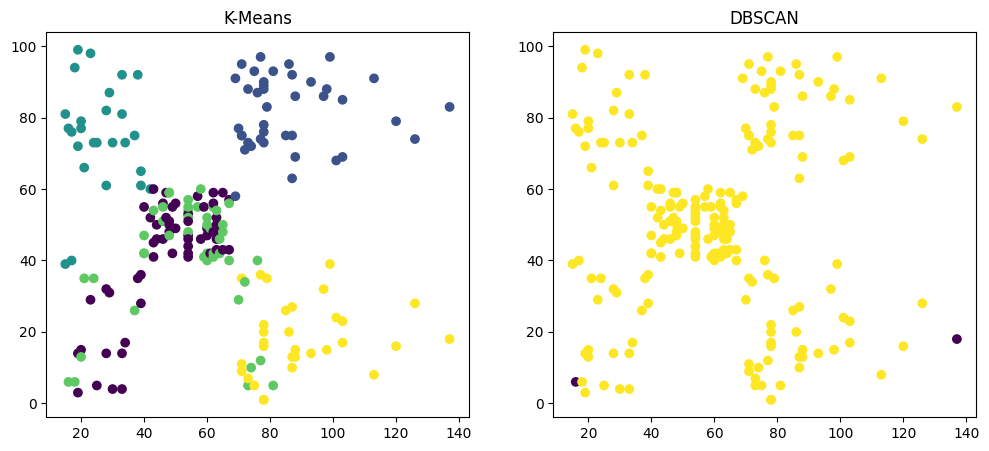

In [6]:
# Ваш код здесь
comparison = pd.DataFrame({
    'Метод': ['K-Means', 'DBSCAN'],
    'Количество кластеров': [5, n_clusters],
    'Silhouette Score': [silhouette_avg, None],
    'Количество выбросов': [0, n_outliers]
})

print(comparison)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=labels_kmeans)
plt.title('K-Means')

plt.subplot(1, 2, 2)
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=labels)
plt.title('DBSCAN')

plt.show()


### Часть 6: Интерпретация результатов

Проанализируйте полученные кластеры.

**Задания:**

1. Для каждого кластера, найденного K-Means, вычислите средние значения признаков:
   - Средний возраст
   - Средний доход
   - Средние расходы
2. Дайте название каждому сегменту (например: "Молодые активные покупатели", "Состоятельные консерваторы" и т.д.) -
- ВИП клиенты,
- Состоятельные консерваторы,
- Системные клиенты,
- Экономные клиенты,
- Нерассудительные молодые клиенты
3. Предложите маркетинговые стратегии для каждого сегмента -
- ВИП клиенты - премиальные товары
- Состоятельные консерваторы - скидки и акции, программы лояльности
- Системные клиенты - тренды, программы лояльности, агитациия "соответствия статусу"
- Экономные клиенты - скиндки, распродажи
- Нерассудительные молодые клиенты - тренды, хайповые товары, агитация "этосовременно молодежно", активные рекламные компании

In [7]:
# Ваш код здесь
df_result = df.copy()
df_result['Cluster'] = labels_kmeans

cluster_summary = df_result.groupby('Cluster')[[
    'Age',
    'Annual Income (k$)',
    'Spending Score (1-100)'
]].mean()

cluster_summary


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,55.275862,47.620690,41.706897
1,32.875000,86.100000,81.525000
2,25.769231,26.115385,74.846154
3,26.733333,54.311111,40.911111
4,44.387097,89.774194,18.483871


## 5. Требования к сдаче работы

Вы должны предоставить:

1. Jupyter Notebook с полным кодом решения и комментариями
2. Все визуализации:
   - Гистограммы распределения признаков
   - Scatter plots для пар признаков
   - График метода локтя
   - Визуализация кластеров для K-Means
   - Визуализация кластеров для DBSCAN
3. Таблицу со средними значениями признаков для каждого кластера
4. Текстовый анализ:
   - Выбор оптимального K для K-Means (обоснование)
   - Выбор оптимальных параметров для DBSCAN (обоснование)
   - Сравнение методов
   - Интерпретация сегментов и предложения по маркетинговым стратегиям

---

## 6. Критерии оценки

Работа оценивается по следующим критериям:

- Корректность выполнения всех заданий (предобработка, кластеризация, визуализация)
- Качество визуализаций (подписи осей, легенда, читаемость)
- Глубина анализа (обоснование выбора параметров, интерпретация результатов)
- Сравнение методов (аргументированные выводы)
- Качество кода (читаемость, комментарии)

---

Удачи в выполнении задания! При возникновении вопросов обращайтесь в чат курса.